<a href="https://colab.research.google.com/github/vitorbborges/ANTHEM/blob/develop/src/geolocate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

# # Replace with your actual project path
# %cd /content/drive/MyDrive/ANTHEM/src
# !ls -a

In [3]:
import geopandas as gpd
import zipfile
from pathlib import Path
from shapely.ops import substring, linemerge
from load_data import *
import tempfile
import shutil
import matplotlib.pyplot as plt

In [4]:
data = load_var(subject_id=1, variable="CO2")
data['index'] = data.index
data

/home/vitor/.local/share/mamba/envs/anthem/lib/python3.11/site-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)
/home/vitor/Desktop/Education/Laurea Magistrale/2 semester - spring 2025/Applied Statistics/ANTHEM/src/load_data.py:50: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'A' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  data_df.loc[data_df["location"] == i*10000, "location"] = state


,CO2,signal,location,regime,index
0,1030.695381,0.0,A,static,0
1,1052.020894,0.0,A,static,1
2,1071.102377,0.0,A,static,2
3,1087.935351,0.0,A,static,3
4,1102.533810,0.0,A,static,4
...,...,...,...,...,...
5841,90.451462,0.0,GH,dynamic,5841
5842,66.961660,0.0,GH,dynamic,5842
5843,44.771347,0.0,GH,dynamic,5843
5844,23.962254,0.0,GH,dynamic,5844


In [5]:
kmz_path = '../data/raw_data/route.kmz'

# Create a temporary directory
with tempfile.TemporaryDirectory() as tmpdir:
    tmpdir_path = Path(tmpdir)

    # Extract the KMZ to the temp folder
    with zipfile.ZipFile(kmz_path, 'r') as z:
        z.extractall(tmpdir_path)

    # Read the KML file (usually named 'doc.kml')
    kml_path = tmpdir_path / 'doc.kml'
    gdf = gpd.read_file(kml_path, driver='KML')

In [6]:
gdf

,Name,Description,geometry
0,Directions from A: Inside laboratory to A: Ins...,,"LINESTRING Z (9.22704 45.47223 0, 9.22738 45.4..."
1,A: Inside laboratory,,POINT Z (9.22704 45.47223 0)
2,B: Gas station,,POINT Z (9.23441 45.47286 0)
3,C: Park,,POINT Z (9.23544 45.47605 0)
4,D: Intersection with traffic light,,POINT Z (9.23435 45.48027 0)
5,E: Train station,,POINT Z (9.23644 45.48479 0)
6,F: Small park (ARPA station),,POINT Z (9.23131 45.47852 0)
7,G: Low traffic street,,POINT Z (9.22738 45.47227 0)
8,A: Inside laboratory,,POINT Z (9.22704 45.47223 0)


In [7]:
route = gdf['geometry'][0]
points = gdf['geometry'][1:]

In [8]:
# 1) grab your closed LineString
line = gdf.geometry.iloc[0]

# 2) extract & dedupe your 8 “cut” points, then project & sort them
pts = gdf.geometry.iloc[1:].drop_duplicates().to_list()
dists = sorted(line.project(pt) for pt in pts)

# 3) build the wrap‑around piece (last → first)
wrap = linemerge([
    substring(line, dists[-1], line.length),
    substring(line, 0.0,      dists[0])
])

# 4) build the in‑between pieces (1→2, 2→3, …)
segs = [wrap] + [
    substring(line, a, b)
    for a, b in zip(dists[:-1], dists[1:])
]

# 5) turn into a GeoSeries
segments_series = gpd.GeoSeries(segs, crs=gdf.crs)


In [9]:
# create another column in a geodataframe segs
segments_df = gpd.GeoDataFrame({'geometry': segments_series})
segments_df['location'] = ["FG", "GH", "AB", "BC", "CD", "DE", "EF"]
segments_df

,geometry,location
0,"LINESTRING Z (9.23131 45.47852 0, 9.23116 45.4...",FG
1,"LINESTRING Z (9.22704 45.47223 0, 9.22738 45.4...",GH
2,"LINESTRING Z (9.22738 45.47227 0, 9.22738 45.4...",AB
3,"LINESTRING Z (9.23441 45.47286 0, 9.23441 45.4...",BC
4,"LINESTRING Z (9.23544 45.47605 0, 9.23544 45.4...",CD
5,"LINESTRING Z (9.23435 45.48027 0, 9.23435 45.4...",DE
6,"LINESTRING Z (9.23644 45.48479 0, 9.23662 45.4...",EF


In [10]:
S_dynamic = data[data["regime"] == "dynamic"]
S_dynamic

,CO2,signal,location,regime,index
309,1141.098310,10000.0,AB,dynamic,309
310,1151.149919,0.0,AB,dynamic,310
311,1161.216422,0.0,AB,dynamic,311
312,1171.258341,0.0,AB,dynamic,312
313,1181.045329,0.0,AB,dynamic,313
...,...,...,...,...,...
5841,90.451462,0.0,GH,dynamic,5841
5842,66.961660,0.0,GH,dynamic,5842
5843,44.771347,0.0,GH,dynamic,5843
5844,23.962254,0.0,GH,dynamic,5844


In [11]:
import numpy as np
import geopandas as gpd

# 1) Merge S_dynamic with your segments GeoDataFrame
#    (assumes segments_df has columns ['location','geometry'])
sd = S_dynamic.merge(
    segments_df[['location','geometry']],
    on='location',
    how='left'
)

# 2) Prepare an empty column for the interpolated Points
sd['sample_pt'] = None

# 3) For each segment, evenly space the points
for loc, group in sd.groupby('location'):
    seg = group.geometry.iloc[0]         # the LineString for this location
    L   = seg.length                     # its total length
    N   = len(group)                     # how many samples to place

    # choose your scheme:
    #  - including endpoints: np.linspace(0   , L, N)
    #  - *excluding* endpoints:     np.linspace(0.5, L-0.5, N) /or/ (np.arange(N)+0.5)/N * L
    dists = np.linspace(0, L, N)         # here we *include* start & end

    # interpolate each distance into a Point
    pts = [seg.interpolate(d) for d in dists]

    # write them back into sd, preserving original row‐order
    sd.loc[group.index, 'sample_pt'] = pts

# 4) Extract X/Y (and Z, if present)
sd['x'] = sd['sample_pt'].apply(lambda p: p.x)
sd['y'] = sd['sample_pt'].apply(lambda p: p.y)
# if 3D:
# sd['z'] = sd['sample_pt'].apply(lambda p: p.z)

# Inspect
print(sd[['location','sample_pt','x','y']].head())


  location                               sample_pt        x          y
0       AB          POINT Z (9.22738 45.4722709 0)  9.22738  45.472271
1       AB  POINT Z (9.22738 45.472284363825565 0)  9.22738  45.472284
2       AB   POINT Z (9.22738 45.47229782765114 0)  9.22738  45.472298
3       AB   POINT Z (9.22738 45.47231129147671 0)  9.22738  45.472311
4       AB   POINT Z (9.22738 45.47232475530228 0)  9.22738  45.472325


In [12]:
sd

,CO2,signal,location,regime,index,geometry,sample_pt,x,y
0,1141.098310,10000.0,AB,dynamic,309,"LINESTRING Z (9.22738 45.47227 0, 9.22738 45.4...",POINT Z (9.22738 45.4722709 0),9.22738,45.472271
1,1151.149919,0.0,AB,dynamic,310,"LINESTRING Z (9.22738 45.47227 0, 9.22738 45.4...",POINT Z (9.22738 45.472284363825565 0),9.22738,45.472284
2,1161.216422,0.0,AB,dynamic,311,"LINESTRING Z (9.22738 45.47227 0, 9.22738 45.4...",POINT Z (9.22738 45.47229782765114 0),9.22738,45.472298
3,1171.258341,0.0,AB,dynamic,312,"LINESTRING Z (9.22738 45.47227 0, 9.22738 45.4...",POINT Z (9.22738 45.47231129147671 0),9.22738,45.472311
4,1181.045329,0.0,AB,dynamic,313,"LINESTRING Z (9.22738 45.47227 0, 9.22738 45.4...",POINT Z (9.22738 45.47232475530228 0),9.22738,45.472325
...,...,...,...,...,...,...,...,...,...
3722,90.451462,0.0,GH,dynamic,5841,"LINESTRING Z (9.22704 45.47223 0, 9.22738 45.4...",POINT Z (9.22738 45.47225871935483 0),9.22738,45.472259
3723,66.961660,0.0,GH,dynamic,5842,"LINESTRING Z (9.22704 45.47223 0, 9.22738 45.4...",POINT Z (9.22738 45.47226176451613 0),9.22738,45.472262
3724,44.771347,0.0,GH,dynamic,5843,"LINESTRING Z (9.22704 45.47223 0, 9.22738 45.4...",POINT Z (9.22738 45.47226480967742 0),9.22738,45.472265
3725,23.962254,0.0,GH,dynamic,5844,"LINESTRING Z (9.22704 45.47223 0, 9.22738 45.4...",POINT Z (9.22738 45.472267854838705 0),9.22738,45.472268


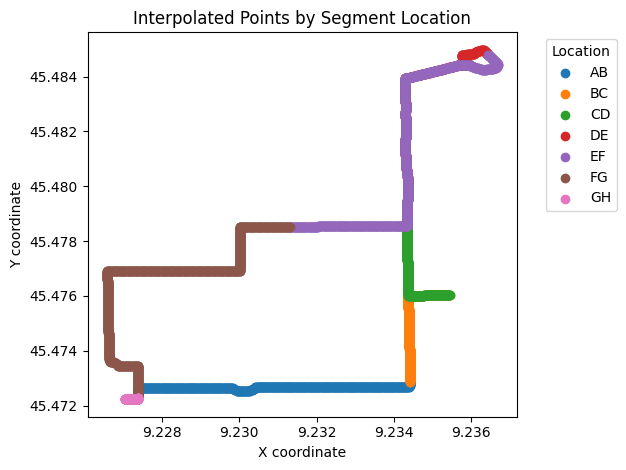

In [13]:
fig, ax = plt.subplots()
for loc, group in sd.groupby('location'):
    ax.scatter(group['x'], group['y'], label=loc)
ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
ax.set_title('Interpolated Points by Segment Location')
ax.legend(title='Location', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [23]:
kmz_path_pts = '../data/raw_data/points_of_interest.kmz'

# Create a temporary directory
with tempfile.TemporaryDirectory() as tmpdir:
    tmpdir_path = Path(tmpdir)

    # Extract the KMZ to the temp folder
    with zipfile.ZipFile(kmz_path_pts, 'r') as z:
        z.extractall(tmpdir_path)

    # Read the KML file (usually named 'doc.kml')
    kml_path = tmpdir_path / 'doc.kml'
    gdf_points = gpd.read_file(kml_path, driver='KML')

gdf_points.rename(columns={'Name': 'location'}, inplace=True)
gdf_points["x"] = gdf_points.geometry.x
gdf_points["y"] = gdf_points.geometry.y
gdf_points = gdf_points[['location', 'x', 'y']]

In [24]:
S_static = data[data["regime"] == "static"]
S_static = S_static.merge(gdf_points, on="location", how="left").drop_duplicates()
S_static

,CO2,signal,location,regime,index,x,y
0,1030.695381,0.0,A,static,0,9.226882,45.472154
1,1052.020894,0.0,A,static,1,9.226882,45.472154
2,1071.102377,0.0,A,static,2,9.226882,45.472154
3,1087.935351,0.0,A,static,3,9.226882,45.472154
4,1102.533810,0.0,A,static,4,9.226882,45.472154
...,...,...,...,...,...,...,...
2114,749.258443,0.0,G,static,5716,9.227272,45.472226
2115,748.398339,0.0,G,static,5717,9.227272,45.472226
2116,747.709314,0.0,G,static,5718,9.227272,45.472226
2117,747.216207,0.0,G,static,5719,9.227272,45.472226


In [25]:
S_dynamic = sd.drop(columns=["sample_pt", "geometry"])
S_dynamic

,CO2,signal,location,regime,index,x,y
0,1141.098310,10000.0,AB,dynamic,309,9.22738,45.472271
1,1151.149919,0.0,AB,dynamic,310,9.22738,45.472284
2,1161.216422,0.0,AB,dynamic,311,9.22738,45.472298
3,1171.258341,0.0,AB,dynamic,312,9.22738,45.472311
4,1181.045329,0.0,AB,dynamic,313,9.22738,45.472325
...,...,...,...,...,...,...,...
3722,90.451462,0.0,GH,dynamic,5841,9.22738,45.472259
3723,66.961660,0.0,GH,dynamic,5842,9.22738,45.472262
3724,44.771347,0.0,GH,dynamic,5843,9.22738,45.472265
3725,23.962254,0.0,GH,dynamic,5844,9.22738,45.472268


In [26]:
S = pd.concat([S_static, S_dynamic], ignore_index=True)
S.sort_values(by=["index"], inplace=True)
S.drop(columns=["index"], inplace=True)
S.to_csv("../data/processed_data/S1CO2-approx-coordinates.csv", index=False)
S

,CO2,signal,location,regime,x,y
0,1030.695381,0.0,A,static,9.226882,45.472154
1,1052.020894,0.0,A,static,9.226882,45.472154
2,1071.102377,0.0,A,static,9.226882,45.472154
3,1087.935351,0.0,A,static,9.226882,45.472154
4,1102.533810,0.0,A,static,9.226882,45.472154
...,...,...,...,...,...,...
5841,90.451462,0.0,GH,dynamic,9.227380,45.472259
5842,66.961660,0.0,GH,dynamic,9.227380,45.472262
5843,44.771347,0.0,GH,dynamic,9.227380,45.472265
5844,23.962254,0.0,GH,dynamic,9.227380,45.472268
